In [64]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_confusion_matrix
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv('AirPass.csv')
df = df.drop(df.columns[0], axis=1)
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [7]:
df.isna().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [8]:
arrival_median = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(arrival_median)

In [9]:
print('Mean:', round(df['Arrival Delay in Minutes'].mean(), 2))

Mean: 15.13


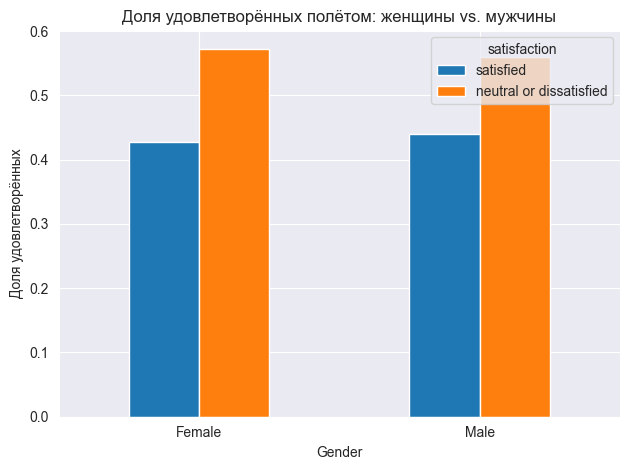

In [25]:
pivot_gender = pd.pivot_table(
    df,
    index='Gender',
    columns=['satisfaction'],
    aggfunc='size'
)
rates_gender = pivot_gender.div(pivot_gender.sum(axis=1), axis=0)

rates_gender[['satisfied', 'neutral or dissatisfied']].plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Доля удовлетворённых')
plt.title('Доля удовлетворённых полётом: женщины vs. мужчины')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
pivot_travel_type = pd.pivot_table(
    df,
    index='Type of Travel',
    columns=['satisfaction'],
    aggfunc='size'
)
pivot_travel_type

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,29909,41746
Personal Travel,28970,3279


In [35]:
pivot_travel_class = pd.pivot_table(
    df,
    index='Class',
    columns=['satisfaction'],
    aggfunc='size'
)
pivot_travel_class.div(pivot_travel_class.sum(axis=1), axis=0) * 100

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.574852,69.425148
Eco,81.386245,18.613755
Eco Plus,75.393648,24.606352


In [36]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [38]:
df = pd.get_dummies(df)

In [40]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)

In [44]:
scaler = StandardScaler()
scaler.fit(X_train, y_train)

X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [47]:
lg = LogisticRegression()
lg.fit(X_train_scaled, y_train)

y_pred = lg.predict(X_test_scaled)

print("F1 score:", round(f1_score(y_test, y_pred), 3))

F1 score: 0.855


In [50]:
abc = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=26),
    learning_rate=0.01,
    random_state=26
)
abc.fit(X_train_scaled, y_train)

y_pred = abc.predict(X_test_scaled)

print("F1 score:", round(f1_score(y_test, y_pred), 3))

F1 score: 0.941


In [58]:
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=params,
    cv=3
)

grid_search.fit(X_train_scaled, y_train)

y_pred = grid_search.predict(X_test_scaled)

print("F1 score:", round(f1_score(y_test, y_pred), 3))

F1 score: 0.951


In [60]:
xc = XGBClassifier(random_state=26)
xc.fit(X_train_scaled, y_train)

y_pred = xc.predict(X_test_scaled)

print("F1 score:", round(f1_score(y_test, y_pred), 3))

F1 score: 0.957


In [62]:
cb = CatBoostClassifier(random_state=26)
cb.fit(X_train_scaled, y_train)

y_pred = cb.predict(X_test_scaled)

print("F1 score:", round(f1_score(y_test, y_pred), 3))

Learning rate set to 0.068023
0:	learn: 0.6018180	total: 67.7ms	remaining: 1m 7s
1:	learn: 0.5020757	total: 75ms	remaining: 37.4s
2:	learn: 0.4472475	total: 82.8ms	remaining: 27.5s
3:	learn: 0.4028686	total: 90.2ms	remaining: 22.5s
4:	learn: 0.3674732	total: 97.2ms	remaining: 19.4s
5:	learn: 0.3397845	total: 105ms	remaining: 17.5s
6:	learn: 0.3121216	total: 114ms	remaining: 16.1s
7:	learn: 0.2917502	total: 122ms	remaining: 15.2s
8:	learn: 0.2749039	total: 130ms	remaining: 14.3s
9:	learn: 0.2575191	total: 137ms	remaining: 13.6s
10:	learn: 0.2473690	total: 145ms	remaining: 13s
11:	learn: 0.2377533	total: 153ms	remaining: 12.6s
12:	learn: 0.2279310	total: 161ms	remaining: 12.2s
13:	learn: 0.2212511	total: 168ms	remaining: 11.8s
14:	learn: 0.2100357	total: 175ms	remaining: 11.5s
15:	learn: 0.2025732	total: 183ms	remaining: 11.2s
16:	learn: 0.1942301	total: 190ms	remaining: 11s
17:	learn: 0.1877937	total: 197ms	remaining: 10.8s
18:	learn: 0.1832382	total: 206ms	remaining: 10.7s
19:	learn: 0

In [77]:
cm = get_confusion_matrix(cb, Pool(X_test_scaled, y_test))
print(cm)

[[11433.   240.]
 [  467.  8641.]]


In [78]:
importances = cb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feat_imp = feat_imp.sort_values('importance', ascending=False)
print(feat_imp)

                              feature  importance
6               Inflight wifi service    25.29583
4                      Type of Travel    18.52534
11                    Online boarding     7.53813
2                       Customer Type     7.31323
22                     Class_Business     5.50635
17                    Checkin service     3.84356
3                                 Age     3.82388
16                   Baggage handling     3.58377
9                       Gate location     3.16379
12                       Seat comfort     2.95215
18                   Inflight service     2.86016
13             Inflight entertainment     2.59530
0                                  id     1.99766
5                     Flight Distance     1.69416
7   Departure/Arrival time convenient     1.53507
8              Ease of Online booking     1.51488
19                        Cleanliness     1.51240
14                   On-board service     1.45450
15                   Leg room service     1.23748
